In [2]:
import os
import random
import numpy as np
import pandas as pd

import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from tqdm.auto import tqdm

import optuna

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [3]:
#Cek apakah GPU tersedia
print("="*50)

print("Torch Version :", torch.__version__)

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA :", torch.version.cuda)

    device = torch.device("cuda")

else:

    print("Menggunakan CPU")

    device = torch.device("cpu")

print("="*50)

Torch Version : 2.11.0+cu128
CUDA Available : True
GPU : NVIDIA GeForce RTX 3060 Ti
CUDA : 12.8


In [4]:
#Load dataset
DATA_PATH = "../output/dataset_preprocessing.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

df.head()

(20807, 9)


,label,author,comment,id,channel,title,cleaning,casefolding,hasil_preprocessing
0,1,Abatistalima-b4t,"AЕR𝐎𝟴𝟴 gua main dikit aja, saldo lngsg nambah",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 gua main dikit aja saldo lngsg nambah,aero88 gua main dikit aja saldo lngsg nambah,aero88 gua main dikit aja saldo lngsg nambah
1,1,AbdulkadirMustafa-z4t,Sebelumnya bermain di tempat lain terasa kuran...,CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,Sebelumnya bermain di tempat lain terasa kuran...,sebelumnya bermain di tempat lain terasa kuran...,sebelumnya bermain di tempat lain terasa kuran...
2,1,abdullaGodgift-m1w,AЕR𝐎𝟴𝟴 aku sih gmpang bgt dapet WEDEY gede dsini,CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 aku sih gmpang bgt dapet WEDEY gede dsini,aero88 aku sih gmpang bgt dapet wedey gede dsini,aero88 aku sih gmpang bgt dapet wedey gede dsini
3,1,AbdullahFABIAN-i2m,"AЕR𝐎𝟴𝟴 gua cba bentar, eh lgnsung dapet jackpot",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 gua cba bentar eh lgnsung dapet jackpot,aero88 gua cba bentar eh lgnsung dapet jackpot,aero88 gua cba bentar eh lgnsung dapet jackpot
4,1,Abergerontorres-s3d,"AЕR𝐎𝟴𝟴 aku cba maen, malah jackpot gede",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 aku cba maen malah jackpot gede,aero88 aku cba maen malah jackpot gede,aero88 aku cba maen malah jackpot gede


In [5]:
DATA_PATH = "../output/dataset_preprocessing.csv"

df = pd.read_csv(DATA_PATH)

print("="*50)
print("Ukuran Dataset :", df.shape)
print("="*50)

print(df[["hasil_preprocessing", "label"]].head())

print("\nDistribusi Label")

print(df["label"].value_counts())

print("\nPersentase")

print(df["label"].value_counts(normalize=True)*100)

Ukuran Dataset : (20807, 9)
                                 hasil_preprocessing  label
0       aero88 gua main dikit aja saldo lngsg nambah      1
1  sebelumnya bermain di tempat lain terasa kuran...      1
2   aero88 aku sih gmpang bgt dapet wedey gede dsini      1
3     aero88 gua cba bentar eh lgnsung dapet jackpot      1
4             aero88 aku cba maen malah jackpot gede      1

Distribusi Label
label
1    10532
0    10275
Name: count, dtype: int64

Persentase
label
1    50.617581
0    49.382419
Name: proportion, dtype: float64


In [6]:
print(df.isnull().sum())

label                    0
author                   0
comment                  0
id                       0
channel                  0
title                    0
cleaning               102
casefolding            102
hasil_preprocessing    102
dtype: int64


In [7]:
df = df.dropna(subset=["hasil_preprocessing"])

In [8]:
#split dataset menjadi train dan test
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("="*50)

print("Train      :", len(train_df))
print("Validation :", len(valid_df))
print("Test       :", len(test_df))

print("="*50)

Train      : 16564
Validation : 2070
Test       : 2071


In [9]:
print("Train")
print(train_df["label"].value_counts(normalize=True))

print()

print("Validation")
print(valid_df["label"].value_counts(normalize=True))

print()

print("Test")
print(test_df["label"].value_counts(normalize=True))

Train
label
1    0.508694
0    0.491306
Name: proportion, dtype: float64

Validation
label
1    0.508696
0    0.491304
Name: proportion, dtype: float64

Test
label
1    0.50845
0    0.49155
Name: proportion, dtype: float64


In [10]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [11]:
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [12]:
sample = train_df["hasil_preprocessing"].iloc[0]

encoding = tokenizer(
    sample,
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH
)

print(sample)
print()
print(encoding.keys())

jane roy suryo iku orang apa c kk ngeyel melu gregeten q

KeysView({'input_ids': [2, 20979, 6064, 25281, 880, 30360, 232, 387, 61, 7819, 21968, 6885, 30366, 147, 30360, 19924, 12123, 30355, 903, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [13]:
from torch.utils.data import Dataset

class IndoBERTDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length):

        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {

            "input_ids": encoding["input_ids"].flatten(),

            "attention_mask": encoding["attention_mask"].flatten(),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )

        }

In [14]:
train_dataset = IndoBERTDataset(

    train_df["hasil_preprocessing"],
    train_df["label"],
    tokenizer,
    MAX_LENGTH

)

valid_dataset = IndoBERTDataset(

    valid_df["hasil_preprocessing"],
    valid_df["label"],
    tokenizer,
    MAX_LENGTH

)

test_dataset = IndoBERTDataset(

    test_df["hasil_preprocessing"],
    test_df["label"],
    tokenizer,
    MAX_LENGTH

)

print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

16564
2070
2071


In [45]:
def objective(trial):
    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        5e-5,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [8, 16, 32]
    )

    epochs = trial.suggest_int(
        "epochs",
        2,
        5
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )

    model.to(device)

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate
    )

    total_steps = len(train_loader) * epochs

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    best_val_f1 = 0.0
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            device
        )

        val_loss, val_acc, val_f1 = eval_epoch(
            model,
            valid_loader,
            device
        )
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )
        
        return best_val_f1

In [46]:
study = optuna.create_study(
    direction="maximize"
)

[I 2026-08-19 09:51:23,785] A new study created in memory with name: no-name-399b1f1c-2688-4020-b0cb-e9c6d219c056


In [47]:
study.optimize(
    objective,
    n_trials=5
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training:   0%|          | 0/2071 [00:00<?, ?it/s]

Validation:   0%|          | 0/259 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

[I 2026-08-19 10:08:26,551] Trial 4 finished with value: 0.9748457522543901 and parameters: {'learning_rate': 1.5050722368232847e-05, 'batch_size': 16, 'epochs': 3}. Best is trial 2 with value: 0.9754253308128544.


Epoch 1/3 | Train Loss: 0.1216 | Train Acc: 0.9630 | Val Loss: 0.0901 | Val Acc: 0.9744 | Val F1: 0.9748


In [48]:
print("Best Trial:")
print(study.best_trial)

print("\nBest Parameters:")
print(study.best_params)

print("\nBest Validation F1:")
print(study.best_value)

Best Trial:
FrozenTrial(number=2, state=<TrialState.COMPLETE: 1>, values=[0.9754253308128544], datetime_start=datetime.datetime(2026, 8, 19, 9, 58, 10, 146683), datetime_complete=datetime.datetime(2026, 8, 19, 10, 1, 23, 376930), params={'learning_rate': 2.7628505430926452e-05, 'batch_size': 16, 'epochs': 3}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'learning_rate': FloatDistribution(high=5e-05, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(8, 16, 32)), 'epochs': IntDistribution(high=5, log=False, low=2, step=1)}, trial_id=2, value=None)

Best Parameters:
{'learning_rate': 2.7628505430926452e-05, 'batch_size': 16, 'epochs': 3}

Best Validation F1:
0.9754253308128544


In [49]:
best_lr = study.best_params["learning_rate"]
best_batch_size = study.best_params["batch_size"]
best_epochs = study.best_params["epochs"]

print("Best Learning Rate:", best_lr)
print("Best Batch Size:", best_batch_size)
print("Best Epochs:", best_epochs)

Best Learning Rate: 2.7628505430926452e-05
Best Batch Size: 16
Best Epochs: 3


In [50]:
final_train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True
)

final_valid_loader = DataLoader(
    valid_dataset,
    batch_size=best_batch_size,
    shuffle=False
)

final_test_loader = DataLoader(
    test_dataset,
    batch_size=best_batch_size,
    shuffle=False
)

In [51]:
final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

final_model.to(device)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [52]:
final_optimizer = AdamW(
    final_model.parameters(),
    lr=best_lr
)

In [53]:
final_total_steps = len(final_train_loader) * best_epochs

final_scheduler = get_linear_schedule_with_warmup(
    final_optimizer,
    num_warmup_steps=0,
    num_training_steps=final_total_steps
)

In [54]:
best_final_val_f1 = 0.0

for epoch in range(best_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{best_epochs}")
    print(f"{'='*50}")

    train_loss, train_acc = train_epoch(
        final_model,
        final_train_loader,
        final_optimizer,
        final_scheduler,
        device
    )

    val_loss, val_acc, val_f1 = eval_epoch(
        final_model,
        final_valid_loader,
        device
    )

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val F1     : {val_f1:.4f}")

    if val_f1 > best_final_val_f1:
        best_final_val_f1 = val_f1


Epoch 1/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss : 0.1230
Train Acc  : 0.9628
Val Loss   : 0.1063
Val Acc    : 0.9696
Val F1     : 0.9699

Epoch 2/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss : 0.0658
Train Acc  : 0.9792
Val Loss   : 0.1005
Val Acc    : 0.9725
Val F1     : 0.9730

Epoch 3/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss : 0.0384
Train Acc  : 0.9861
Val Loss   : 0.1088
Val Acc    : 0.9705
Val F1     : 0.9710


In [55]:
final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

final_model.to(device)

final_optimizer = AdamW(
    final_model.parameters(),
    lr=best_lr
)

final_total_steps = len(final_train_loader) * best_epochs

final_scheduler = get_linear_schedule_with_warmup(
    final_optimizer,
    num_warmup_steps=0,
    num_training_steps=final_total_steps
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [56]:
best_final_val_f1 = 0.0
best_final_epoch = 0

In [57]:
import os

FINAL_MODEL_PATH = "../model/indobert_optuna_best"
os.makedirs(FINAL_MODEL_PATH, exist_ok=True)

for epoch in range(best_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{best_epochs}")
    print(f"{'='*50}")

    train_loss, train_acc = train_epoch(
        final_model,
        final_train_loader,
        final_optimizer,
        final_scheduler,
        device
    )

    val_loss, val_acc, val_f1 = eval_epoch(
        final_model,
        final_valid_loader,
        device
    )

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val F1     : {val_f1:.4f}")

    if val_f1 > best_final_val_f1:
        best_final_val_f1 = val_f1
        best_final_epoch = epoch + 1

        final_model.save_pretrained(FINAL_MODEL_PATH)
        tokenizer.save_pretrained(FINAL_MODEL_PATH)

        print("Model terbaik disimpan.")


Epoch 1/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss : 0.1210
Train Acc  : 0.9633
Val Loss   : 0.1019
Val Acc    : 0.9725
Val F1     : 0.9730


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model terbaik disimpan.

Epoch 3/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]

Train Loss : 0.0381
Train Acc  : 0.9859
Val Loss   : 0.1106
Val Acc    : 0.9700
Val F1     : 0.9706


In [58]:
print("Best Final Epoch:", best_final_epoch)
print("Best Final Validation F1:", best_final_val_f1)
print("Model path:", FINAL_MODEL_PATH)

Best Final Epoch: 2
Best Final Validation F1: 0.9744560075685903
Model path: ../model/indobert_optuna_best


In [59]:
best_model = AutoModelForSequenceClassification.from_pretrained(
    FINAL_MODEL_PATH,
    num_labels=2
)

best_model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_model.eval()

test_predictions = []
test_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = best_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        test_predictions.extend(predictions.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(test_labels, test_predictions)
test_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)
test_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)
test_f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1-score  : {test_f1:.4f}")

Testing:   0%|          | 0/130 [00:00<?, ?it/s]

Test Accuracy  : 0.9807
Test Precision : 0.9703
Test Recall    : 0.9924
Test F1-score  : 0.9812


In [61]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=[
            "Bukan Promosi Judi Online",
            "Promosi Judi Online"
        ],
        digits=4
    )
)

print("Confusion Matrix:")
print(confusion_matrix(test_labels, test_predictions))

Classification Report:
                           precision    recall  f1-score   support

Bukan Promosi Judi Online     0.9920    0.9686    0.9801      1018
      Promosi Judi Online     0.9703    0.9924    0.9812      1053

                 accuracy                         0.9807      2071
                macro avg     0.9811    0.9805    0.9807      2071
             weighted avg     0.9809    0.9807    0.9807      2071

Confusion Matrix:
[[ 986   32]
 [   8 1045]]


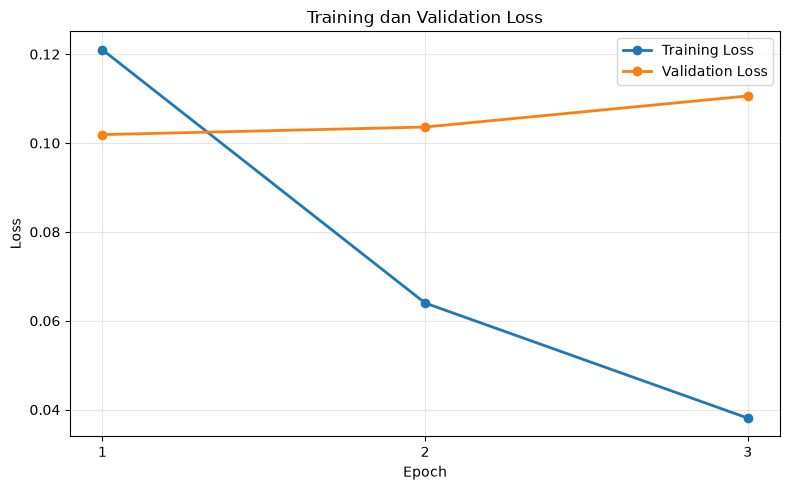

In [62]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]

train_loss = [0.1210, 0.0640, 0.0381]
val_loss = [0.1019, 0.1036, 0.1106]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'training_validation_loss_optuna.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

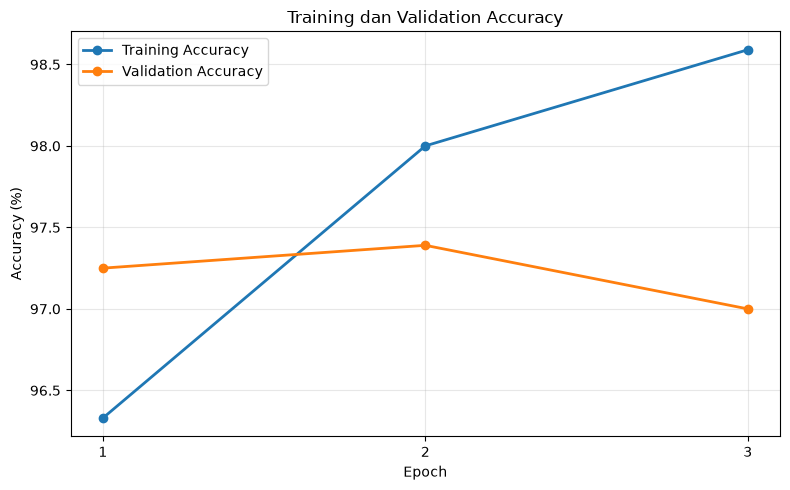

In [64]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]

train_acc = [96.33, 98.00, 98.59]
val_acc = [97.25, 97.39, 97.00]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_acc,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    epochs,
    val_acc,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title('Training dan Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'training_validation_accuracy_optuna.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [15]:
BATCH_SIZE = 16

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

In [17]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)

print(batch["attention_mask"].shape)

print(batch["labels"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [18]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=2

)

model.to(device)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [19]:
EPOCHS = 3

LEARNING_RATE = 2e-5

In [20]:
from torch.optim import AdamW

optimizer = AdamW(

    model.parameters(),

    lr=LEARNING_RATE

)

In [21]:
from transformers import get_linear_schedule_with_warmup

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(

    optimizer,

    num_warmup_steps=0,

    num_training_steps=total_steps

)

In [22]:
from sklearn.metrics import accuracy_score

def train_epoch(model, dataloader, optimizer, scheduler, device):

    model.train()

    total_loss = 0
    predictions = []
    labels = []

    for batch in tqdm(dataloader, desc="Training"):

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        target = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=target
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        labels.extend(target.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(labels, predictions)

    return avg_loss, accuracy

In [23]:
from sklearn.metrics import accuracy_score, f1_score

def eval_epoch(model, dataloader, device):

    model.eval()

    total_loss = 0
    predictions = []
    labels = []

    with torch.no_grad():

        for batch in tqdm(dataloader, desc="Validation"):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            target = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=target
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            labels.extend(target.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions, zero_division=0)

    return avg_loss, accuracy, f1

In [24]:
EPOCHS = 3

best_accuracy = 0

history = {

    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []

}

In [25]:
import os

MODEL_PATH = "../model/indobert_best"

os.makedirs(MODEL_PATH, exist_ok=True)

for epoch in range(EPOCHS):

    print("="*60)
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("="*60)

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        device
    )

    val_loss, val_acc, val_f1 = eval_epoch(
        model,
        valid_loader,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print()

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")

    print()

    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val F1     : {val_f1:.4f}")

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        model.save_pretrained(MODEL_PATH)

        tokenizer.save_pretrained(MODEL_PATH)

        print("\nModel terbaik disimpan.")

Epoch 1/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]


Train Loss : 0.1183
Train Acc  : 0.9643

Val Loss   : 0.0944
Val Acc    : 0.9720
Val F1     : 0.9725


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/130 [00:00<?, ?it/s]


Train Loss : 0.0651
Train Acc  : 0.9795

Val Loss   : 0.0927
Val Acc    : 0.9710
Val F1     : 0.9716
Epoch 3/3


Training:   0%|          | 0/1036 [00:00<?, ?it/s]

Validation:   0%|          | 0/130 [00:00<?, ?it/s]


Train Loss : 0.0379
Train Acc  : 0.9857

Val Loss   : 0.1090
Val Acc    : 0.9715
Val F1     : 0.9720


In [26]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    "../output/training_history.csv",
    index=False
)

history_df.head()

,train_loss,train_acc,val_loss,val_acc,val_f1
0,0.118329,0.964320,0.094364,0.971981,0.972486
1,0.065072,0.979474,0.092731,0.971014,0.971564
2,0.037910,0.985692,0.109023,0.971498,0.972025


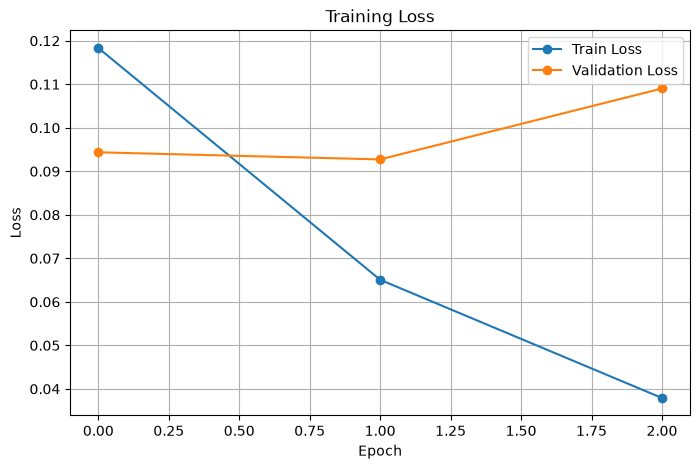

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid(True)

plt.show()

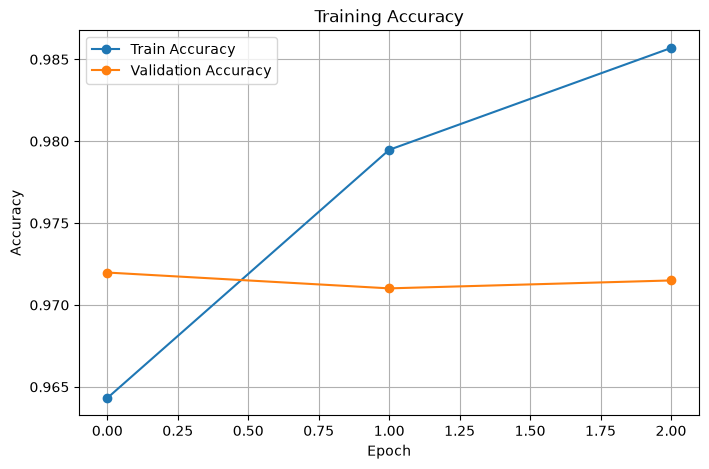

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.grid(True)

plt.show()